## Multiple Linear Regression Model on red_wine_dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("05_red_wine.csv")
df.head()

,fixedd acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixedd acidity        1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe

<bound method NDFrame.describe of       fixedd acidity  volatile acidity  citric acid  residual sugar  \
0                7.4             0.700         0.00             1.9   
1                7.8             0.880         0.00             2.6   
2                7.8             0.760         0.04             2.3   
3               11.2             0.280         0.56             1.9   
4                7.4             0.700         0.00             1.9   
...              ...               ...          ...             ...   
1594             6.2             0.600         0.08             2.0   
1595             5.9             0.550         0.10             2.2   
1596             6.3             0.510         0.13             2.3   
1597             5.9             0.645         0.12             2.0   
1598             6.0             0.310         0.47             3.6   

      chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0         0.076                 11.0

In [7]:
df.isnull().sum()

fixedd acidity          0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
df.isnull().mean()*100

fixedd acidity          0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

In [9]:
df[df.duplicated()]

,fixedd acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(1359, 12)

In [16]:
df.corr()

,fixedd acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixedd acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


In [20]:
corr = df.corr(numeric_only=True)
corr["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixedd acidity          0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64

<Axes: >

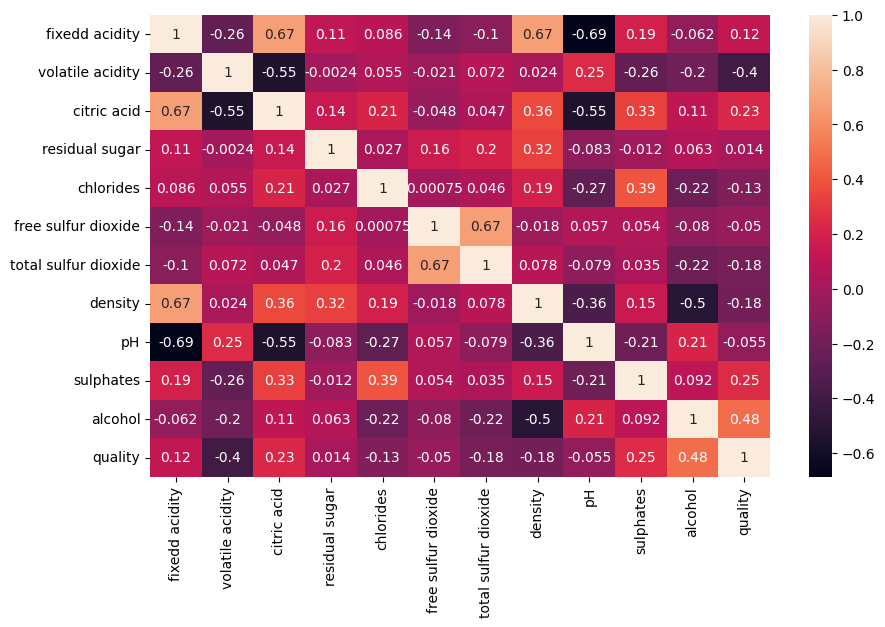

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True)

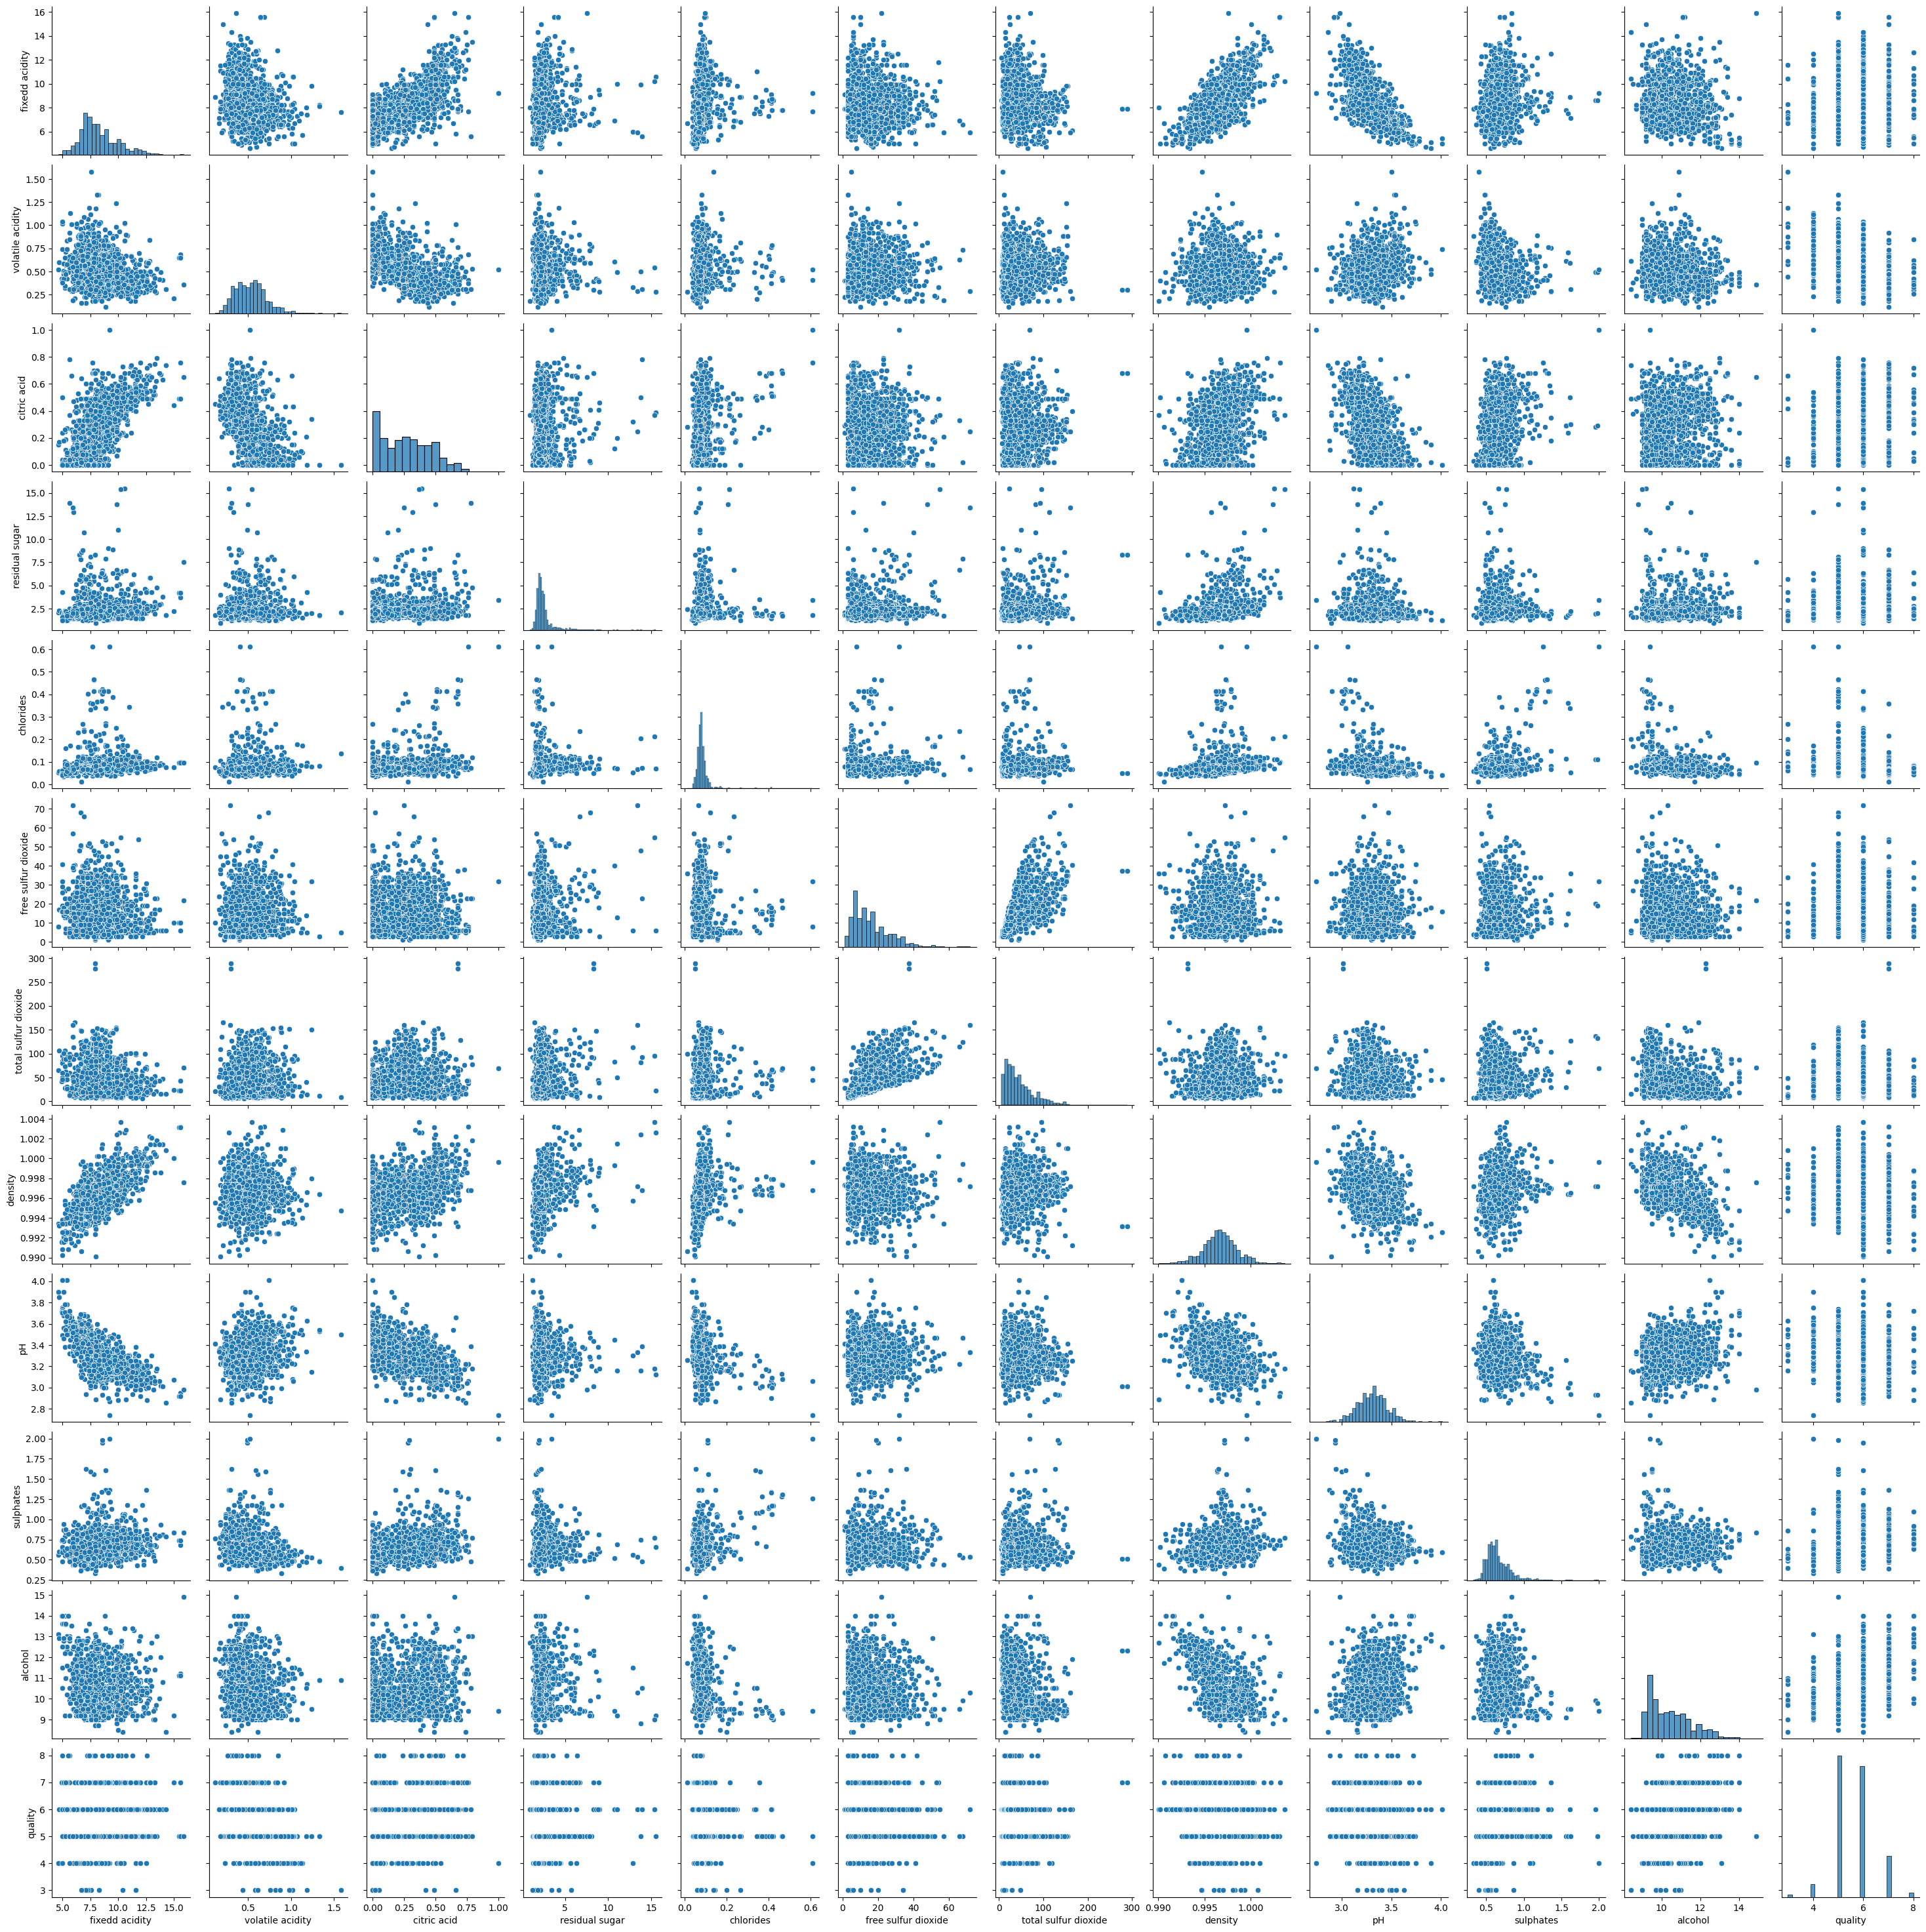

In [18]:
sns.pairplot(df)

# Model 1 (Keeping all Independent features)

In [28]:
X = df[["alcohol","volatile acidity","sulphates","citric acid","fixedd acidity","residual sugar","chlorides","free sulfur dioxide",	"total sulfur dioxide",	"density",	"pH"]]
Y = df["quality"]

In [29]:
X

,alcohol,volatile acidity,sulphates,citric acid,fixedd acidity,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH
0,9.4,0.700,0.56,0.00,7.4,1.9,0.076,11.0,34.0,0.99780,3.51
1,9.8,0.880,0.68,0.00,7.8,2.6,0.098,25.0,67.0,0.99680,3.20
2,9.8,0.760,0.65,0.04,7.8,2.3,0.092,15.0,54.0,0.99700,3.26
3,9.8,0.280,0.58,0.56,11.2,1.9,0.075,17.0,60.0,0.99800,3.16
5,9.4,0.660,0.56,0.00,7.4,1.8,0.075,13.0,40.0,0.99780,3.51
...,...,...,...,...,...,...,...,...,...,...,...
1593,9.5,0.620,0.82,0.08,6.8,1.9,0.068,28.0,38.0,0.99651,3.42
1594,10.5,0.600,0.58,0.08,6.2,2.0,0.090,32.0,44.0,0.99490,3.45
1595,11.2,0.550,0.76,0.10,5.9,2.2,0.062,39.0,51.0,0.99512,3.52
1597,10.2,0.645,0.71,0.12,5.9,2.0,0.075,32.0,44.0,0.99547,3.57


In [30]:
Y

0       5
1       5
2       5
3       6
5       5
       ..
1593    6
1594    5
1595    6
1597    5
1598    6
Name: quality, Length: 1359, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.20,random_state=42)

In [34]:
X_train.shape

(1087, 11)

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [38]:
X_train

array([[ 1.98424001, -0.82832312,  0.51985077, ..., -0.56629785,
        -0.98661183, -0.25982192],
       [-0.2158671 ,  0.96589124, -0.45848943, ..., -0.59634157,
        -0.02550786,  0.85726724],
       [-0.39920936,  0.18092246, -0.17074231, ..., -0.35599181,
         0.05503158,  0.85726724],
       ...,
       [-0.76589387, -0.32370033, -0.05564346, ..., -0.26586066,
        -0.62686901, -0.06268854],
       [-0.03252484, -1.16473831, -0.6311377 , ..., -0.83669132,
        -0.53559097, -0.91693319],
       [ 0.88418646, -1.05259991, -0.6311377 , ..., -0.86673504,
        -1.49132565, -0.85122206]], shape=(1087, 11))

In [39]:
from sklearn.linear_model import LinearRegression
regression= LinearRegression()

In [40]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 0.33,-0.18, 0.15,...,-0.12, 0.04,-0.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.637
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[58.3 ,45.62,41.01,...,19.26,13.92, 7.99]"


In [41]:
y_pred = regression.predict(X_test)


y_pred

array([5.22642315, 5.84382382, 6.38844249, 5.11223104, 5.26725629,
       6.84992475, 5.67762696, 4.82863436, 5.80793872, 5.73187899,
       6.31321361, 5.85663854, 5.99276719, 5.41890444, 6.33839085,
       5.17864281, 6.00418589, 5.27964281, 5.26633616, 5.85409346,
       5.24245521, 6.23134879, 5.23098318, 4.71826987, 5.73416538,
       4.77603328, 5.67783594, 5.44166201, 5.26353839, 5.48143328,
       6.06274508, 6.3613023 , 5.76185212, 4.74121413, 5.72916944,
       6.3410215 , 4.78617754, 5.90809094, 5.33485232, 6.166198  ,
       5.32208103, 5.7221856 , 6.01755043, 4.61032765, 5.48697495,
       5.46474249, 5.07962952, 4.39823333, 5.2250385 , 5.84147584,
       5.71082662, 6.04800974, 5.90765594, 5.58856055, 6.30502795,
       5.12871309, 5.28477916, 5.21157201, 5.00429302, 6.05031441,
       4.88069229, 6.12157269, 5.18188676, 5.91334212, 5.7021316 ,
       5.96336615, 5.05730379, 5.43770319, 6.07453916, 6.07282777,
       5.51267478, 6.14015007, 5.92792846, 6.02843734, 5.88626

In [42]:
#Performance metrics
from sklearn.metrics import mean_absolute_error , mean_squared_error
mse = mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

0.4315233074982079
0.5002077096149883
0.6569043366413468


In [43]:
## R2 value 
from sklearn.metrics import r2_score
score = r2_score(Y_test,y_pred)
print(score)

## Adjusted R2 value 
print(1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1))

0.39080999900876967
0.3650365758899099


# Model 2 (Including only important features based on correlation)

In [44]:
df.corr()

,fixedd acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixedd acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


In [45]:
X = df[["alcohol","volatile acidity","sulphates","citric acid"]]
Y = df["quality"]

In [46]:
from sklearn.model_selection import train_test_split 
X_train,  X_test, Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)


In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


In [51]:
X_test

array([[-0.88087245,  0.41734404, -0.79379463, -1.16487801],
       [ 0.4600679 ,  0.49227313,  0.60492947, -0.85894288],
       [ 0.74741227, -0.8314742 ,  0.98639968,  0.82370035],
       ...,
       [ 0.07694209, -0.68161601,  0.73208621,  0.26281927],
       [ 1.80100826, -0.58171055, -0.09443258,  0.00787333],
       [-1.07243536,  0.26748585, -0.03085421, -1.36883476]],
      shape=(272, 4))

In [55]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()


In [58]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.34,-0.22, 0.11,-0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.637
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[44.64,32.28,28.95,21.8 ]"


In [61]:
y_pred = regression.predict(X_test)
y_pred

array([5.17712519, 5.761742  , 6.16618551, 5.15868554, 5.30828231,
       6.7798448 , 5.63116733, 4.89733492, 5.93890311, 5.57077572,
       6.29543017, 5.73586625, 6.05627691, 5.53907727, 6.18338287,
       5.21956485, 5.83077627, 5.42702435, 5.25147686, 5.92828685,
       5.36173303, 6.05147103, 5.40553142, 4.74811016, 5.71471045,
       5.0753229 , 5.63922385, 5.33759671, 5.33277391, 5.3900738 ,
       6.0211993 , 6.37476013, 5.73937062, 4.61702375, 5.5924801 ,
       6.30945855, 4.90220251, 5.94454903, 5.39794507, 6.16139199,
       5.3646931 , 5.54951902, 5.96329568, 4.8495075 , 5.44907086,
       5.36837795, 5.04651695, 4.489262  , 5.19877125, 5.78281472,
       6.05665276, 6.41147305, 5.84037957, 5.62710105, 6.22753946,
       5.31867582, 5.16898175, 5.21741862, 5.05958039, 5.78429765,
       5.05541063, 5.81088622, 5.10976551, 5.95732777, 5.71089321,
       5.84726872, 5.17977242, 5.26358322, 6.12503903, 6.05433089,
       5.32992066, 6.29236676, 5.88478521, 6.0367914 , 5.86668

In [65]:
#Perfromance Metrics
from sklearn.metrics import mean_absolute_error , mean_squared_error 
mse = mean_absolute_error(y_pred,Y_test)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

0.4991033038835481
0.4991033038835481
0.7064724367472153


In [66]:
from sklearn.metrics import r2_score
score = r2_score(Y_test,y_pred)
print(score)


0.41047251178614386


In [72]:
train_score = regression.score(X_train,Y_train)
test_score = regression.score(X_test,Y_test)
print(train_score)
print(test_score)

0.3218509108670211
0.41047251178614386


#### Conclusion

This Linear Regression model achieved an R² score of 0.41.

The model has limited performance because the relationship between the input features and wine quality is not completely linear.

Linear Regression can only capture linear patterns, while this dataset likely contains more complex relationships.

More advanced models such as Ridge, Lasso, Decision Tree, or Random Forest may provide better performance